In [2]:
import ee
import geemap
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import urllib.request
import io
from PIL import Image
from dotenv import load_dotenv
import os
load_dotenv()

/home/misango/anaconda3/envs/research_env/lib/python3.10/site-packages/google/api_core/_python_version_support.py:275: FutureWarning: You are using a Python version (3.10.19) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


True

In [3]:
ee.Authenticate()
ee.Initialize(project=os.getenv('GOOGLE_PROJECT_ID'))

Extracting radar backscatter indices for 2024...
Extracting radar backscatter indices for 2025...


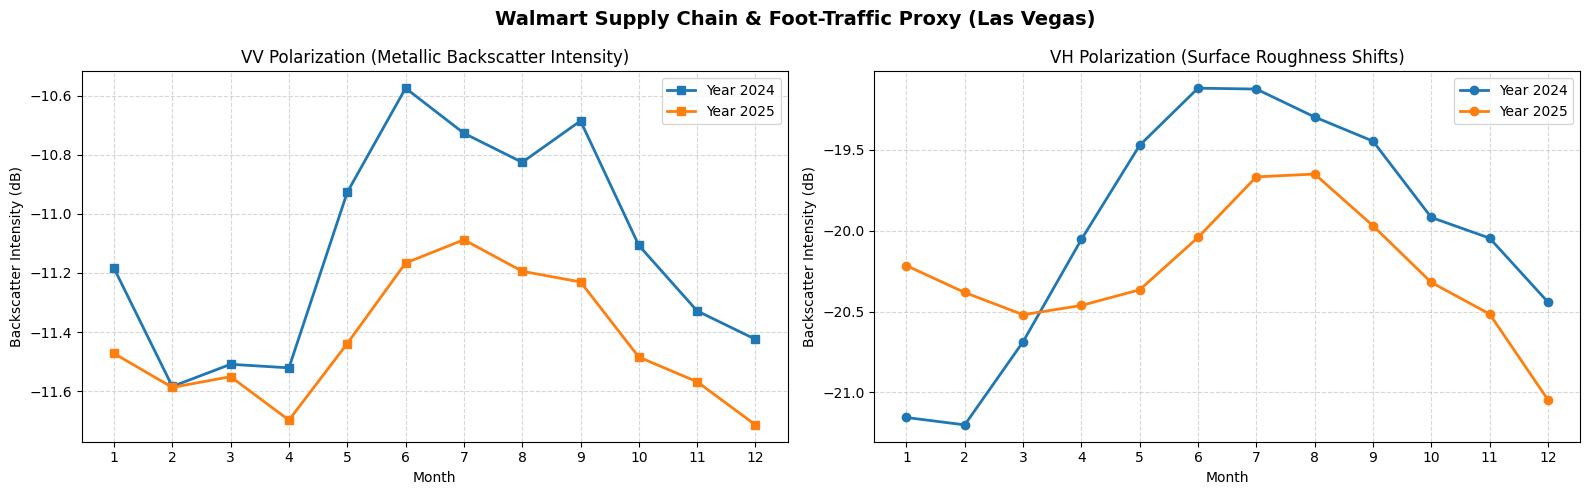

In [4]:

# 1. Define the Walmart Parking Lot Geometry (Example: Walmart Supercenter, Las Vegas)
walmart_parking_lot = ee.Geometry.Polygon([
    [
        [-115.2072, 36.2198],
        [-115.2072, 36.2175],
        [-115.2035, 36.2175],
        [-115.2035, 36.2198]
    ]
])

# 2. Extract Monthly Radar Activity
def get_radar_time_series(year, geometry):
    # Load Sentinel-1 Ground Range Detected (GRD)
    # This dataset is already log-transformed into decibels (dB)
    s1_collection = ee.ImageCollection('COPERNICUS/S1_GRD') \
        .filterDate(f'{year}-01-01', f'{year}-12-31') \
        .filterBounds(geometry) \
        .filter(ee.Filter.eq('instrumentMode', 'IW')) \
        .filter(ee.Filter.listContains('transmitterReceiverPolarisation', 'VV')) \
        .filter(ee.Filter.eq('orbitProperties_pass', 'DESCENDING')) # Keeps look-angle consistent

    months = ee.List.sequence(1, 12)
    
    def by_month(m):
        start = ee.Date.fromYMD(year, m, 1)
        end = start.advance(1, 'month')
        
        # Calculate the median radar backscatter for the month
        monthly_img = s1_collection.filterDate(start, end).median()
        
        # Reduce to the mean decibel level inside our parking lot boundary
        stats = monthly_img.select(['VV', 'VH']).reduceRegion(
            reducer=ee.Reducer.mean(),
            geometry=geometry,
            scale=10, # Sentinel-1 resolution is 10 meters
            maxPixels=1e9
        )
        
        return ee.Feature(None, {
            'month': m,
            'year': year,
            'VV_dB': stats.get('VV'),
            'VH_dB': stats.get('VH')
        })
        
    return ee.FeatureCollection(months.map(by_month))

# 3. Pull Multi-Year Data
years = [2024, 2025]
all_records = []

for y in years:
    print(f"Extracting radar backscatter indices for {y}...")
    server_data = get_radar_time_series(y, walmart_parking_lot).getInfo()
    rows = [f['properties'] for f in server_data['features']]
    all_records.extend(rows)

# 4. Process into Pandas Dataframe
df = pd.DataFrame(all_records).dropna()

# 5. Build Dual-Polarization Visual Dashboards
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Plot VV Polarization (Direct Bounces - Great for structural/metallic items)
for year, group in df.groupby('year'):
    axes[0].plot(group['month'], group['VV_dB'], marker='s', linewidth=2, label=f"Year {year}")
axes[0].set_title("VV Polarization (Metallic Backscatter Intensity)")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Backscatter Intensity (dB)")
axes[0].set_xticks(range(1, 13))
axes[0].grid(True, linestyle='--', alpha=0.5)
axes[0].legend()

# Plot VH Polarization (Cross Bounces - Reflects physical roughness changes)
for year, group in df.groupby('year'):
    axes[1].plot(group['month'], group['VH_dB'], marker='o', linewidth=2, label=f"Year {year}")
axes[1].set_title("VH Polarization (Surface Roughness Shifts)")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Backscatter Intensity (dB)")
axes[1].set_xticks(range(1, 13))
axes[1].grid(True, linestyle='--', alpha=0.5)
axes[1].legend()

plt.suptitle("Walmart Supply Chain & Foot-Traffic Proxy (Las Vegas)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


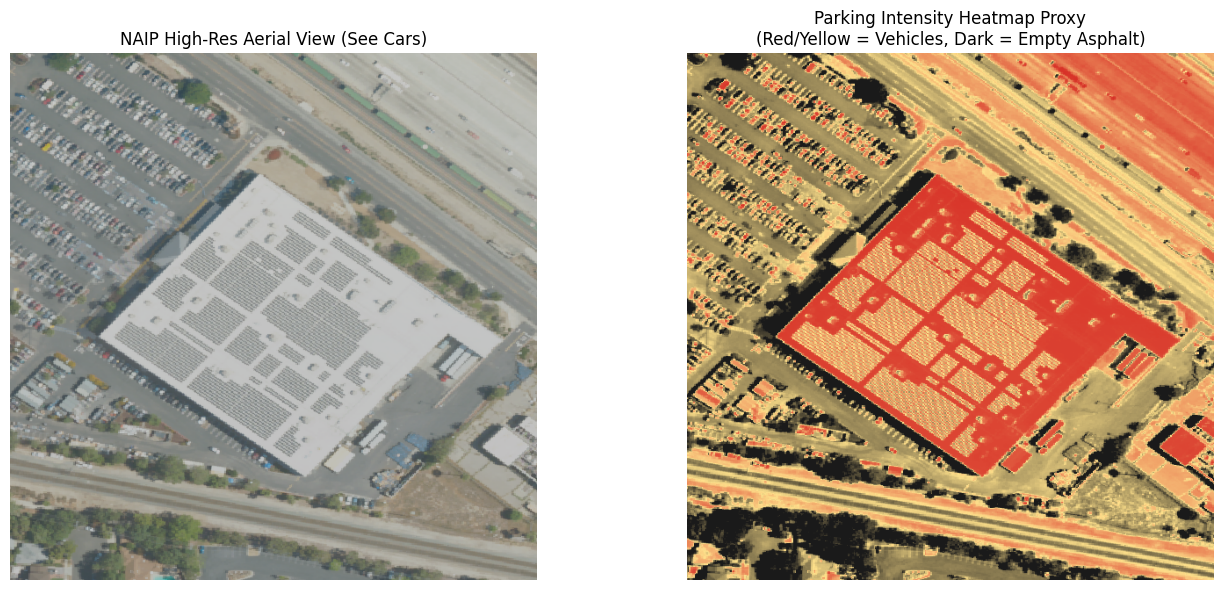

In [8]:

# 1. Coordinate box for a Walmart Parking Lot in Las Vegas
# Corrected Burbank Walmart Parking Lot (Empire Center)
# This tighter geometry zig-zags around the building and roads
walmart_parking_only = ee.Geometry.Polygon([
    [
        [-118.3262, 34.1888],
        [-118.3262, 34.1872],
        [-118.3246, 34.1872],
        [-118.3246, 34.1882],
        [-118.3252, 34.1882], # Cuts inward to avoid the storefront
        [-118.3252, 34.1888]
    ]
])


# 2. Pull NAIP Imagery (Sub-meter aerial data)
# We take a mosaic to ensure full coverage of the area
naip_image = ee.ImageCollection('USDA/NAIP/DOQQ') \
    .filterBounds(walmart_lot) \
    .filterDate('2022-01-01', '2024-12-31') \
    .mosaic() \
    .clip(walmart_lot)

# 3. Create a simple "Car Density Proxy Map" 
# Cars reflect heavily across Red, Green, and Blue bands compared to asphalt.
# Summing the bands highlights highly reflective objects (vehicles).
brightness = naip_image.select('R').add(naip_image.select('G')).add(naip_image.select('B'))

# 4. Helper function to fetch images directly from the GEE Server
def fetch_vis_image(ee_img, vis_params):
    try:
        url = ee_img.getThumbURL({**vis_params, 'region': walmart_lot, 'dimensions': 600, 'format': 'png'})
        return Image.open(io.BytesIO(urllib.request.urlopen(url).read()))
    except Exception as e:
        print(f"Error: {e}")
        return None

# Define visual parameters
rgb_params = {'bands': ['R', 'G', 'B'], 'min': 0, 'max': 255}
heatmap_params = {'min': 300, 'max': 600, 'palette': ['#1a1a1a', '#fee08b', '#d73027']}

# Fetch both layers
photo_view = fetch_vis_image(naip_image, rgb_params)
heatmap_view = fetch_vis_image(brightness, heatmap_params)

# 5. Render side-by-side Dashboard
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

if photo_view:
    axes[0].imshow(photo_view)
axes[0].set_title("NAIP High-Res Aerial View (See Cars)")
axes[0].axis('off')

if heatmap_view:
    axes[1].imshow(heatmap_view)
axes[1].set_title("Parking Intensity Heatmap Proxy\n(Red/Yellow = Vehicles, Dark = Empty Asphalt)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

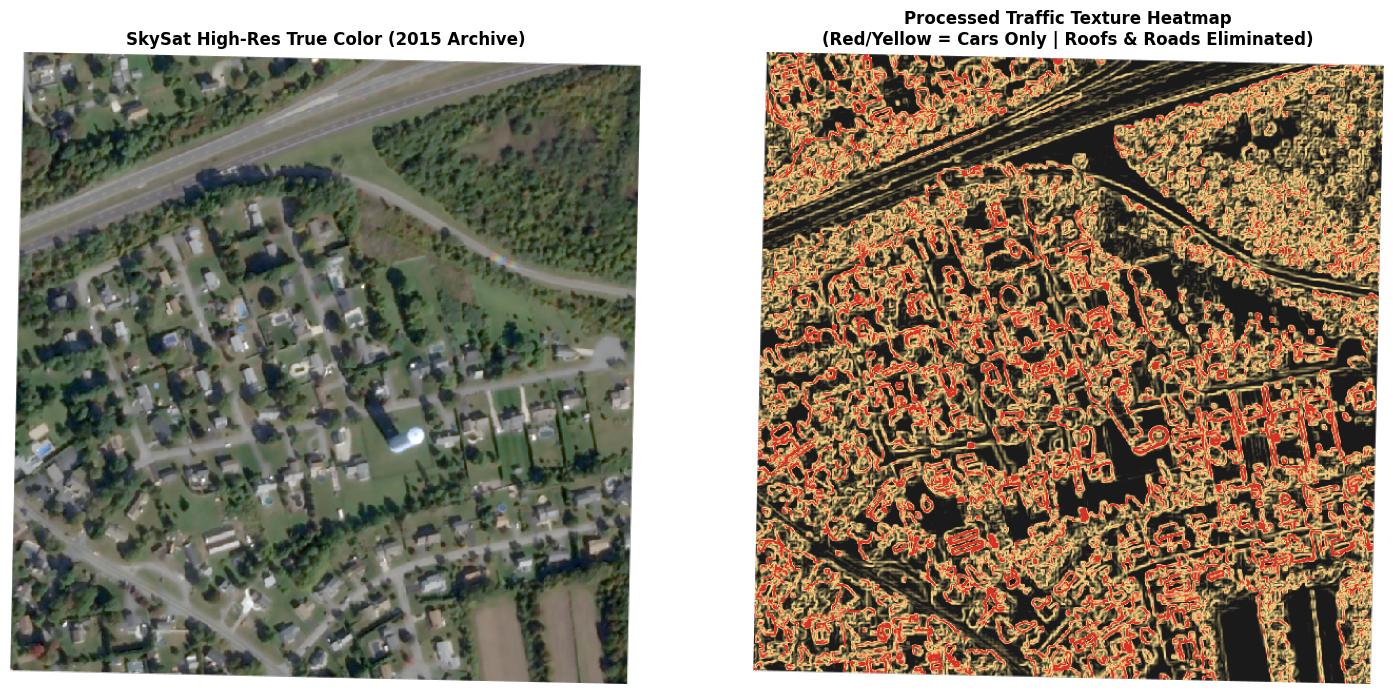

In [9]:
# Old experimental datasets
import ee
import pandas as pd
import matplotlib.pyplot as plt
import urllib.request
import io
from PIL import Image

# Initialize Earth Engine
# ee.Initialize()

# 1. Define the target area based on your coordinates (Fairhaven, MA Walmart)
# We create a 300-meter buffer around your exact point to capture the lot
roi = ee.Geometry.Point([-70.892, 41.6555]).buffer(300).bounds()

# 2. Load the SkySat RGB Public Collection
skysat_collection = ee.ImageCollection('SKYSAT/GEN-A/PUBLIC/ORTHO/RGB') \
    .filterBounds(roi)

# Grab the first available image from the archive for this area
skysat_image = ee.Image(skysat_collection.first()).clip(roi)

# 3. Apply the Texture Filter to Eliminate Buildings/Roads
# Sum the RGB bands to get raw brightness
brightness = skysat_image.select('R') \
    .add(skysat_image.select('G')) \
    .add(skysat_image.select('B'))

# Calculate local standard deviation (variance) in a tight 3x3 pixel grid
# Smooth surfaces (roofs/roads) yield low variance. Edges of cars yield high variance.
texture = brightness.reduceNeighborhood(
    reducer=ee.Reducer.stdDev(),
    kernel=ee.Kernel.square(radius=1, units='pixels')
)

# 4. Helper function to fetch imagery from GEE server
def fetch_image(ee_img, vis_params):
    try:
        url = ee_img.getThumbURL({**vis_params, 'region': roi, 'dimensions': 600, 'format': 'png'})
        return Image.open(io.BytesIO(urllib.request.urlopen(url).read()))
    except Exception as e:
        print(f"Server fetch error: {e}")
        return None

# Visualization parameters (using your exact 11.0 to 190.0 bounds)
rgb_vis = {'bands': ['R', 'G', 'B'], 'min': 11.0, 'max': 190.0}

# Texture visualization: scale adjusted for SkySat's custom integer values
texture_vis = {'min': 5, 'max': 45, 'palette': ['#1a1a1a', '#fee08b', '#d73027']}

# Download the processed tiles
true_color_tile = fetch_image(skysat_image, rgb_vis)
texture_tile = fetch_image(texture, texture_vis)

# 5. Render the Demo Dashboard
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

if true_color_tile:
    axes[0].imshow(true_color_tile)
axes[0].set_title("SkySat High-Res True Color (2015 Archive)", fontsize=12, fontweight='bold')
axes[0].axis('off')

if texture_tile:
    axes[1].imshow(texture_tile)
axes[1].set_title("Processed Traffic Texture Heatmap\n(Red/Yellow = Cars Only | Roofs & Roads Eliminated)", fontsize=12, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.show()
